# Zadanie 3. Podział na społeczności i zgodność z rzeczywistym rozłamem



Kacper Kaszuba

In [ ]:
# import bibliotek
import networkx as nx
from networkx.algorithms.community import girvan_newman, louvain_communities, label_propagation_communities, asyn_fluidc
from networkx.algorithms.community.quality import modularity

import matplotlib.pyplot as plt
import matplotlib.patches as mpatches

import pandas as pd
import numpy as np
import seaborn as sns

import random
from pprint import pprint



### Wybrane algorytmy
- Algorytm Girvana-Newmana
- Metoda Louvaina
- Półsynchroniczna metoda propagacji etykiet
- Asynchronous fluid communities algorithm

### Wybrane miary jakości
- Modularność
- Zgodność z rzeczywistością
- Liczbę węzłów granicznych

In [ ]:
G_zad3 = nx.karate_club_graph()

communities_gn = tuple(sorted(c) for c in next(girvan_newman(G_zad3)))
communities_lv = louvain_communities(G_zad3, seed=42)
communities_lpc = label_propagation_communities(G_zad3)
communities_af = list(asyn_fluidc(G_zad3, k=2, seed = 42))


mod_gn = modularity(G_zad3, communities_gn)
mod_lv = modularity(G_zad3, communities_lv)
mod_lpc = modularity(G_zad3, communities_lpc)
mod_af = modularity(G_zad3, communities_af)

### Modularność

In [ ]:
print(f"Dla algorytmu Girvana-Newmana mamy {communities_gn}\nWartość mod {mod_gn}\n")
print(f"Dla Metoda Louvaina mamy {communities_lv}\nWartość mod {mod_lv}\n")
print(f"Dla Półsynchroniczna metoda propagacji etykiet mamy {communities_lpc}\nWartość mod {mod_lpc}\n")
print(f"Dla Asynchronous fluid communities algorithm mamy {communities_af}\nWartość mod {mod_af}\n")




Dla algorytmu Girvana-Newmana mamy ([0, 1, 3, 4, 5, 6, 7, 10, 11, 12, 13, 16, 17, 19, 21], [2, 8, 9, 14, 15, 18, 20, 22, 23, 24, 25, 26, 27, 28, 29, 30, 31, 32, 33])
Wartość mod 0.3476602762317048

Dla Metoda Louvaina mamy [{1, 2, 3, 7, 12, 13}, {0, 4, 5, 6, 10, 11, 16, 17, 19, 21}, {24, 25, 28, 31}, {32, 33, 8, 9, 14, 15, 18, 20, 22, 23, 26, 27, 29, 30}]
Wartość mod 0.4266224396094526

Dla Półsynchroniczna metoda propagacji etykiet mamy dict_values([{0, 1, 3, 4, 7, 10, 11, 12, 13, 17, 19, 21, 24, 25, 31}, {32, 33, 2, 8, 9, 14, 15, 18, 20, 22, 23, 26, 27, 28, 29, 30}, {16, 5, 6}])
Wartość mod 0.30948632896684847

Dla Asynchronous fluid communities algorithm mamy [{0, 3, 4, 5, 6, 7, 10, 11, 12, 16, 24, 25, 28, 31}, {1, 2, 8, 9, 13, 14, 15, 17, 18, 19, 20, 21, 22, 23, 26, 27, 29, 30, 32, 33}]
Wartość mod 0.22592342722212852



In [ ]:
G_zad3_df = pd.DataFrame(G_zad3.nodes('club'))
G_zad3_df

,0,1
0,0,Mr. Hi
1,1,Mr. Hi
2,2,Mr. Hi
3,3,Mr. Hi
4,4,Mr. Hi
5,5,Mr. Hi
6,6,Mr. Hi
7,7,Mr. Hi
8,8,Mr. Hi
9,9,Officer


In [ ]:
gn_wynik = {}

for nr_grupy, grupa in enumerate(communities_gn):
  for node in grupa:
    gn_wynik[node] = f"Grupa {nr_grupy+1}"

G_zad3_df['GN_pred'] = G_zad3_df[0].map(gn_wynik)
G_zad3_df

,0,1,GN_pred
0,0,Mr. Hi,Grupa 1
1,1,Mr. Hi,Grupa 1
2,2,Mr. Hi,Grupa 2
3,3,Mr. Hi,Grupa 1
4,4,Mr. Hi,Grupa 1
5,5,Mr. Hi,Grupa 1
6,6,Mr. Hi,Grupa 1
7,7,Mr. Hi,Grupa 1
8,8,Mr. Hi,Grupa 2
9,9,Officer,Grupa 2


In [ ]:
lv_wynik = {}

for nr_grupy, grupa in enumerate(communities_lv):
  for node in grupa:
    lv_wynik[node] = f"Grupa {nr_grupy+1}"

G_zad3_df['LV_pred'] = G_zad3_df[0].map(lv_wynik)
G_zad3_df

,0,1,GN_pred,LV_pred
0,0,Mr. Hi,Grupa 1,Grupa 2
1,1,Mr. Hi,Grupa 1,Grupa 1
2,2,Mr. Hi,Grupa 2,Grupa 1
3,3,Mr. Hi,Grupa 1,Grupa 1
4,4,Mr. Hi,Grupa 1,Grupa 2
5,5,Mr. Hi,Grupa 1,Grupa 2
6,6,Mr. Hi,Grupa 1,Grupa 2
7,7,Mr. Hi,Grupa 1,Grupa 1
8,8,Mr. Hi,Grupa 2,Grupa 4
9,9,Officer,Grupa 2,Grupa 4


In [ ]:
lpc_wynik = {}

for nr_grupy, grupa in enumerate(communities_lpc):
  for node in grupa:
    lpc_wynik[node] = f"Grupa {nr_grupy+1}"

G_zad3_df['LPC_pred'] = G_zad3_df[0].map(lpc_wynik)
G_zad3_df

,0,1,GN_pred,LV_pred,LPC_pred
0,0,Mr. Hi,Grupa 1,Grupa 2,Grupa 1
1,1,Mr. Hi,Grupa 1,Grupa 1,Grupa 1
2,2,Mr. Hi,Grupa 2,Grupa 1,Grupa 2
3,3,Mr. Hi,Grupa 1,Grupa 1,Grupa 1
4,4,Mr. Hi,Grupa 1,Grupa 2,Grupa 1
5,5,Mr. Hi,Grupa 1,Grupa 2,Grupa 3
6,6,Mr. Hi,Grupa 1,Grupa 2,Grupa 3
7,7,Mr. Hi,Grupa 1,Grupa 1,Grupa 1
8,8,Mr. Hi,Grupa 2,Grupa 4,Grupa 2
9,9,Officer,Grupa 2,Grupa 4,Grupa 2


In [ ]:
af_wynik = {}

for nr_grupy, grupa in enumerate(communities_af):
  for node in grupa:
    af_wynik[node] = f"Grupa {nr_grupy+1}"

G_zad3_df['AF_pred'] = G_zad3_df[0].map(af_wynik)
G_zad3_df

,0,1,GN_pred,LV_pred,LPC_pred,AF_pred
0,0,Mr. Hi,Grupa 1,Grupa 2,Grupa 1,Grupa 1
1,1,Mr. Hi,Grupa 1,Grupa 1,Grupa 1,Grupa 2
2,2,Mr. Hi,Grupa 2,Grupa 1,Grupa 2,Grupa 2
3,3,Mr. Hi,Grupa 1,Grupa 1,Grupa 1,Grupa 1
4,4,Mr. Hi,Grupa 1,Grupa 2,Grupa 1,Grupa 1
5,5,Mr. Hi,Grupa 1,Grupa 2,Grupa 3,Grupa 1
6,6,Mr. Hi,Grupa 1,Grupa 2,Grupa 3,Grupa 1
7,7,Mr. Hi,Grupa 1,Grupa 1,Grupa 1,Grupa 1
8,8,Mr. Hi,Grupa 2,Grupa 4,Grupa 2,Grupa 2
9,9,Officer,Grupa 2,Grupa 4,Grupa 2,Grupa 2


### Zgodność z rzeczywistością i Liczba węzłów granicznych

In [ ]:
print("Confusion Matrix - GN")
display(pd.crosstab(G_zad3_df[1], G_zad3_df['GN_pred']))

print("Confusion Matrix - LV")
display(pd.crosstab(G_zad3_df[1], G_zad3_df['LV_pred']))

print("Confusion Matrix - LPC")
display(pd.crosstab(G_zad3_df[1], G_zad3_df['LPC_pred']))

print("Confusion Matrix - AF")
display(pd.crosstab(G_zad3_df[1], G_zad3_df['AF_pred']))

Confusion Matrix - GN


GN_pred,Grupa 1,Grupa 2
1,,
Mr. Hi,15,2
Officer,0,17


Confusion Matrix - LV


LV_pred,Grupa 1,Grupa 2,Grupa 3,Grupa 4
1,,,,
Mr. Hi,6,10,0,1
Officer,0,0,4,13


Confusion Matrix - LPC


LPC_pred,Grupa 1,Grupa 2,Grupa 3
1,,,
Mr. Hi,12,2,3
Officer,3,14,0


Confusion Matrix - AF


AF_pred,Grupa 1,Grupa 2
1,,
Mr. Hi,10,7
Officer,4,13


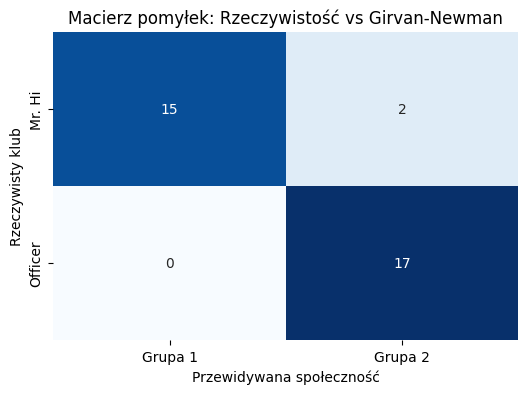

In [ ]:
macierz_gn = pd.crosstab(G_zad3_df[1], G_zad3_df['GN_pred'])

plt.figure(figsize=(6, 4))
sns.heatmap(macierz_gn, annot=True, cmap="Blues", cbar=False)
plt.title("Macierz pomyłek: Rzeczywistość vs Girvan-Newman")
plt.xlabel("Przewidywana społeczność")
plt.ylabel("Rzeczywisty klub")
plt.show()

Wartości Graniczne

In [ ]:
zdrajcy_gn = G_zad3_df[
    (((G_zad3_df[1] ==  'Mr. Hi') & (G_zad3_df['GN_pred'] == 'Grupa 2')) |
    ((G_zad3_df[1] ==  'Officer') & (G_zad3_df['GN_pred'] == 'Grupa 1')) )
]
print("Węzły, z którymi Grivan-Newmian miał problem (graniczne):\n")
display(zdrajcy_gn)

Węzły, z którymi Grivan-Newmian miał problem (graniczne):



,0,1,GN_pred,LV_pred,LPC_pred,AF_pred
2,2,Mr. Hi,Grupa 2,Grupa 1,Grupa 2,Grupa 2
8,8,Mr. Hi,Grupa 2,Grupa 4,Grupa 2,Grupa 2


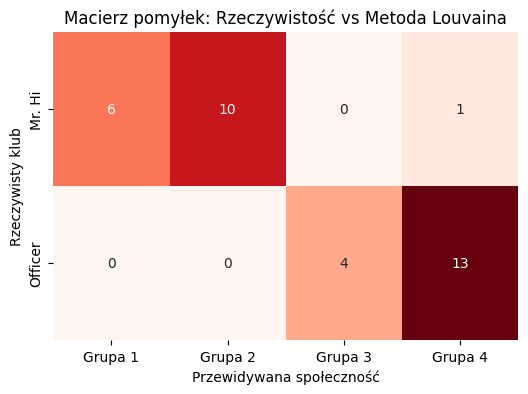

In [ ]:
macierz_lv = pd.crosstab(G_zad3_df[1], G_zad3_df['LV_pred'])

plt.figure(figsize=(6, 4))
sns.heatmap(macierz_lv, annot=True, cmap="Reds", cbar=False)
plt.title("Macierz pomyłek: Rzeczywistość vs Metoda Louvaina")
plt.xlabel("Przewidywana społeczność")
plt.ylabel("Rzeczywisty klub")
plt.show()

Wartości Graniczne

In [ ]:
zdrajcy_lv = G_zad3_df[
    ((G_zad3_df[1] == 'Officer') & (G_zad3_df['LV_pred'].isin(['Grupa 1', 'Grupa 2']))) |
    ((G_zad3_df[1] == 'Mr. Hi') & (G_zad3_df['LV_pred'].isin(['Grupa 3', 'Grupa 4'])))
]
print("Węzły, z którymi Metoda Louvaina miała problem (graniczne):\n")
display(zdrajcy_lv)

Węzły, z którymi Metoda Louvaina miała problem (graniczne):



,0,1,GN_pred,LV_pred,LPC_pred,AF_pred
8,8,Mr. Hi,Grupa 2,Grupa 4,Grupa 2,Grupa 2


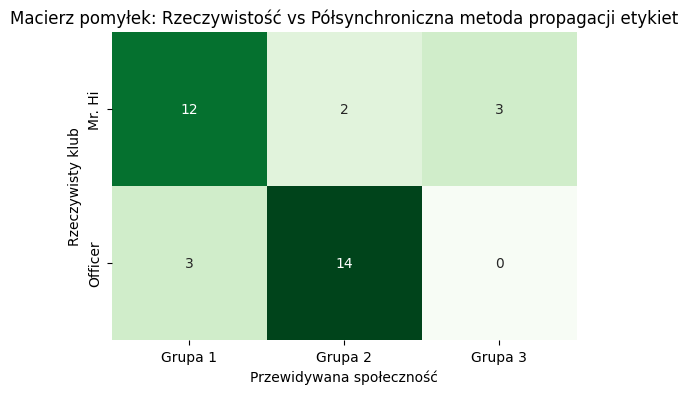

In [ ]:
macierz_lpc = pd.crosstab(G_zad3_df[1], G_zad3_df['LPC_pred'])

plt.figure(figsize=(6, 4))
sns.heatmap(macierz_lpc, annot=True, cmap="Greens", cbar=False)
plt.title("Macierz pomyłek: Rzeczywistość vs Półsynchroniczna metoda propagacji etykiet")
plt.xlabel("Przewidywana społeczność")
plt.ylabel("Rzeczywisty klub")
plt.show()

Wartości Graniczne

In [ ]:
zdrajcy_lpc = G_zad3_df[
    ((G_zad3_df[1] == 'Officer') & (G_zad3_df['LPC_pred'].isin(['Grupa 1', 'Grupa 3']))) |
    ((G_zad3_df[1] == 'Mr. Hi') & (G_zad3_df['LPC_pred'].isin(['Grupa 2'])))
]
print("Węzły, z którymi Półsynchroniczna metoda propagacji etykiet miała problem (graniczne):\n")
display(zdrajcy_lpc)

Węzły, z którymi Półsynchroniczna metoda propagacji etykiet miała problem (graniczne):



,0,1,GN_pred,LV_pred,LPC_pred,AF_pred
2,2,Mr. Hi,Grupa 2,Grupa 1,Grupa 2,Grupa 2
8,8,Mr. Hi,Grupa 2,Grupa 4,Grupa 2,Grupa 2
24,24,Officer,Grupa 2,Grupa 3,Grupa 1,Grupa 1
25,25,Officer,Grupa 2,Grupa 3,Grupa 1,Grupa 1
31,31,Officer,Grupa 2,Grupa 3,Grupa 1,Grupa 1


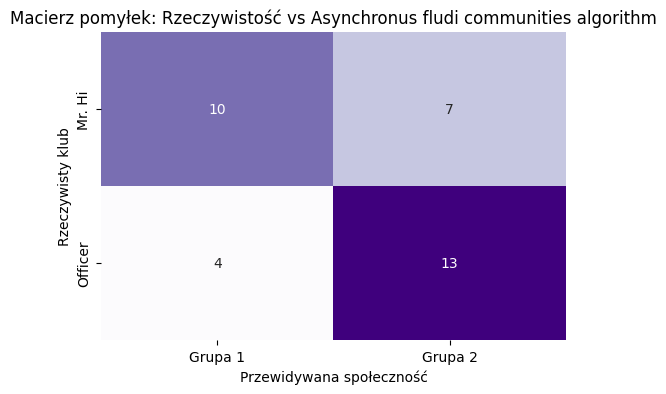

In [ ]:
macierz_af = pd.crosstab(G_zad3_df[1], G_zad3_df['AF_pred'])

plt.figure(figsize=(6, 4))
sns.heatmap(macierz_af, annot=True, cmap="Purples", cbar=False)
plt.title("Macierz pomyłek: Rzeczywistość vs Asynchronus fludi communities algorithm")
plt.xlabel("Przewidywana społeczność")
plt.ylabel("Rzeczywisty klub")
plt.show()

Wartości Graniczne

In [ ]:
zdrajcy_af = G_zad3_df[
    (((G_zad3_df[1] ==  'Mr. Hi') & (G_zad3_df['AF_pred'] == 'Grupa 2')) |
    ((G_zad3_df[1] ==  'Officer') & (G_zad3_df['AF_pred'] == 'Grupa 1')) )
]
print("Węzły, z którymi Asynchronus fludi communities algorithm miał problem (graniczne):\n")
display(zdrajcy_af)

Węzły, z którymi Asynchronus fludi communities algorithm miał problem (graniczne):



,0,1,GN_pred,LV_pred,LPC_pred,AF_pred
1,1,Mr. Hi,Grupa 1,Grupa 1,Grupa 1,Grupa 2
2,2,Mr. Hi,Grupa 2,Grupa 1,Grupa 2,Grupa 2
8,8,Mr. Hi,Grupa 2,Grupa 4,Grupa 2,Grupa 2
13,13,Mr. Hi,Grupa 1,Grupa 1,Grupa 1,Grupa 2
17,17,Mr. Hi,Grupa 1,Grupa 2,Grupa 1,Grupa 2
19,19,Mr. Hi,Grupa 1,Grupa 2,Grupa 1,Grupa 2
21,21,Mr. Hi,Grupa 1,Grupa 2,Grupa 1,Grupa 2
24,24,Officer,Grupa 2,Grupa 3,Grupa 1,Grupa 1
25,25,Officer,Grupa 2,Grupa 3,Grupa 1,Grupa 1
28,28,Officer,Grupa 2,Grupa 3,Grupa 2,Grupa 1


# Notatki i wnioski do Zadania 3

## Porównywane metody:
1. Girvan-Newman (GN):

a. Cechy podziału:
- Podział na 2 grupy
- Wskaźnik `modularity` na poziomie 0.35
- Wyłapuje główne mosty w sieci

b. Błędy i węzły graniczne:
- 2 błędnie przypisane węzły

c. Uzasadnienie:
- Wynik najbardziej zbliżony do historycznej prawdy (klub rozpadł się na 2 obozy). Pomimo niższej modularności, algorytm pomylił się tylko przy 2 osobach.

2. Louvain (LV):

a. Cechy podziału:
- Podział aż na 4 grupy
- Bardzo wysoki wskaźnik `modularity` na poziomie 0.43
- Podejście "od dołu", łączy małe paczki znajomych

b. Błędy i węzły graniczne:
- 1 błędnie przypisany węzeł

c. Uzasadnienie:
- Z matematycznego punktu widzenia to świetny podział (najwyższa modularność), ale historycznie nietrafiony, bo sztucznie dzieli 2 główne obozy na mniejsze podgrupy.

3. Label Propagation (LPC) i Asyn Fluidc (AF):

a. Cechy podziału:
- LPC: 3 grupy, `modularity` 0.31
- AF: 2 grupy, `modularity` 0.23 (najniższa)

b. Błędy i węzły graniczne:
- LPC: 5 błędów
- AF: 11 błędów

c. Uzasadnienie:
- Słabo radzą sobie z tym grafem. Asyn Fluidc dodatkowo zależy od losowych punktów startowych, więc bez ustawienia `seed` jego wyniki ciągle się zmieniają i dają sporo błędów.

## Najtrudniejsze do interpretacji węzły:

a. Cechy:
- Osoby, które przed rozpadem klubu miały znajomych w obu obozach
- Algorytmy przydzielają je różnie w zależności od metody
- Często lądują w osobnych, małych społecznościach (jak w przypadku podziału na 3/4 grupy)

b. Przykładowe węzły:
- nr 2, 8, 24, 25, 31

c. Uzasadnienie:
- Są to klasyczne węzły graniczne (tzw. "zdrajcy"). Dobrym przykładem jest węzeł nr 8 – historycznie poszedł za Mr. Hi, ale miał tak dużo kontaktów z drugą stroną, że prawie każdy algorytm omyłkowo przypisywał go do Officera.

## Najważniejsze obserwacje (Ocena najlepszego podziału):
1. Odp. na "Czy metoda, która daje najwyższą modularność, zawsze najlepiej odtwarza rzeczywisty podział?". Zdecydowanie nie. Louvain miał najwyższą modularność (0.43), ale wygenerował 4 grupy. W rzeczywistości klub podzielił się na 2 obozy, co najlepiej odgadł algorytm Girvan-Newman, chociaż matematycznie miał słabszy wynik (0.35).

2. Odp. na "Które węzły wyglądają na „graniczne” między społecznościami?". Węzły, z którymi algorytmy najczęściej się mylą w macierzach pomyłek (np. nr 8 czy 31). Widać to też wtedy, gdy algorytm tworzy 3 grupę, do której wrzuca "po trochu" osób z obu frakcji, bo nie wie, co z nimi zrobić.

3. Odp. na "Czy wynik zależy od algorytmu lub ziarna losowości?". Bardzo zależy. Algorytmy działające na innej zasadzie dają skrajnie różne podziały (od 2 do 4 grup). Przy algorytmach typu Asyn Fluidc brak `seed` sprawia, że wyniki są za każdym razem inne i mocno chybione (nawet 11 błędnie przypisanych osób).